# EDA — Dacon 이커머스 데이터셋

## 분석 목표
| 섹션 | 내용 |
|------|------|
| 1 | 데이터 개요 |
| 2 | 월별 매출 추이 |
| 3 | 카테고리 분석 |
| 4 | 인구통계 분석 |
| 5 | 쿠폰·할인 효과 |
| 6 | 마케팅 비용 분석 |
| 7 | 지역별 구매 패턴 |
| 8 | 요일별 구매 패턴 |
| 9 | 장바구니 분석 |
| 10 | EDA 인사이트 요약 |

---
## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import URL, create_engine
from dotenv import load_dotenv
import os
from pathlib import Path

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / '.env').exists() and (path / 'sql').is_dir()
)
load_dotenv(PROJECT_ROOT / '.env')

db_url = URL.create(
    'mysql+mysqlconnector',
    username=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    host=os.getenv('DB_HOST'),
    database=os.getenv('DB_NAME'),
)
engine = create_engine(db_url)

# 분석 SQL은 ../sql/01_eda.sql 에 모으고 `-- name:` 마커로 구분한다.
import re
from pathlib import Path

SQL_FILE = PROJECT_ROOT / 'sql' / '01_eda.sql'

def load_queries(path):
    """`-- name: 이름 | 설명` 마커로 SQL을 쪼개 {이름: 쿼리}로 반환."""
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)

def run(name, **kwargs):
    """이름으로 SELECT 쿼리를 실행해 DataFrame 반환."""
    return pd.read_sql(Q[name], engine, **kwargs)

---
## 1. 데이터 로드 및 기본 확인

In [2]:
df = run('orders_all')
df.head()

,고객ID,거래ID,거래날짜,제품ID,제품카테고리,수량,평균금액,배송료,쿠폰상태,연도,...,세후금액,성별,고객지역,가입기간,오프라인비용,온라인비용,거래_배송비,배송비_배부액,최종결제금액,거래_총금액
0,USER_1358,Transaction_0000,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,2019,...,152.17,남,Chicago,12,4500,2424.5,6.5,6.5,158.67,158.67
1,USER_1358,Transaction_0001,2019-01-01,Product_0981,Nest-USA,1,153.71,6.5,Used,2019,...,152.17,남,Chicago,12,4500,2424.5,6.5,6.5,158.67,158.67
2,USER_1358,Transaction_0002,2019-01-01,Product_0904,Office,1,2.05,6.5,Used,2019,...,2.02,남,Chicago,12,4500,2424.5,6.5,6.5,8.52,8.52
3,USER_1358,Transaction_0003,2019-01-01,Product_0203,Apparel,5,17.53,6.5,Not Used,2019,...,103.43,남,Chicago,12,4500,2424.5,6.5,6.5,109.93,775.00
4,USER_1358,Transaction_0003,2019-01-01,Product_0848,Bags,1,16.50,6.5,Used,2019,...,17.52,남,Chicago,12,4500,2424.5,6.5,0.0,17.52,775.00


In [3]:
df.shape

(52924, 28)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52924 entries, 0 to 52923
Data columns (total 28 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   고객ID      52924 non-null  object        
 1   거래ID      52924 non-null  object        
 2   거래날짜      52924 non-null  datetime64[ns]
 3   제품ID      52924 non-null  object        
 4   제품카테고리    52924 non-null  object        
 5   수량        52924 non-null  int64         
 6   평균금액      52924 non-null  float64       
 7   배송료       52924 non-null  float64       
 8   쿠폰상태      52924 non-null  object        
 9   연도        52924 non-null  int64         
 10  월         52924 non-null  int64         
 11  총매출       52924 non-null  float64       
 12  gst       52924 non-null  float64       
 13  쿠폰코드      52924 non-null  object        
 14  할인율       52924 non-null  float64       
 15  할인정보제공여부  52924 non-null  int64         
 16  할인적용여부    52924 non-null  int64         
 17  할인후금액     52

In [5]:
df.describe()

,거래날짜,수량,평균금액,배송료,연도,월,총매출,gst,할인율,할인정보제공여부,할인적용여부,할인후금액,세후금액,가입기간,오프라인비용,온라인비용,거래_배송비,배송비_배부액,최종결제금액,거래_총금액
count,52924,52924.000000,52924.000000,52924.000000,52924.0,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000,52924.000000
mean,2019-07-05 19:16:09.450532864,4.497638,52.237646,10.517630,2019.0,6.652388,88.254754,0.137462,19.850351,0.994993,0.336766,82.372090,91.453824,26.127995,2830.914141,1893.109119,10.517630,4.166770,95.620594,294.209415
min,2019-01-01 00:00:00,1.000000,0.390000,0.000000,2019.0,1.000000,0.400000,0.050000,0.000000,0.000000,0.000000,0.290000,0.320000,2.000000,500.000000,320.250000,0.000000,0.000000,0.320000,6.400000
25%,2019-04-12 00:00:00,1.000000,5.700000,6.000000,2019.0,4.000000,11.960000,0.100000,10.000000,1.000000,0.000000,10.870000,12.590000,15.000000,2500.000000,1252.630000,6.000000,0.000000,14.800000,64.000000
50%,2019-07-13 00:00:00,1.000000,16.990000,6.000000,2019.0,7.000000,30.390000,0.180000,20.000000,1.000000,0.000000,28.140000,33.020000,27.000000,3000.000000,1837.870000,6.000000,0.000000,36.885000,137.400000
75%,2019-09-27 00:00:00,2.000000,102.130000,6.500000,2019.0,9.000000,121.300000,0.180000,30.000000,1.000000,1.000000,119.000000,130.900000,37.000000,3500.000000,2425.350000,6.500000,6.000000,136.900000,283.495000
max,2019-12-31 00:00:00,900.000000,355.740000,521.360000,2019.0,12.000000,10512.390000,0.180000,30.000000,1.000000,1.000000,8545.500000,8972.780000,50.000000,5000.000000,4556.930000,521.360000,521.360000,8979.280000,25458.420000
std,NaN,20.104711,64.006882,19.475613,0.0,3.333364,163.993178,0.045825,8.227229,0.070585,0.472609,154.316005,169.869394,13.478285,936.154247,807.014092,19.475613,10.499075,171.728684,926.504627


In [6]:
print(f"거래 기간: {df['거래날짜'].min().date()} ~ {df['거래날짜'].max().date()}")
print(f"고객 수: {df['고객ID'].nunique():,}명")
print(f"거래 수: {df['거래ID'].nunique():,}건")
print(f"제품 카테고리 수: {df['제품카테고리'].nunique()}개")
print(f"총 세후매출 합계: {df['세후금액'].sum():,.0f}")

거래 기간: 2019-01-01 ~ 2019-12-31
고객 수: 1,468명
거래 수: 25,061건
제품 카테고리 수: 20개
총 세후매출 합계: 4,840,102


---
## 2. 매출 트렌드 (월별)

In [7]:
monthly = run('monthly_sales')
monthly

,월,총매출,거래건수,고객수
0,1,434840.0,2102,215
1,2,325906.0,1664,109
2,3,354212.0,1991,208
3,4,435947.0,1813,224
4,5,324075.0,2034,200
5,6,323446.0,1940,259
6,7,403135.0,2080,236
7,8,414591.0,2414,300
8,9,355472.0,1932,193
9,10,434788.0,2125,210


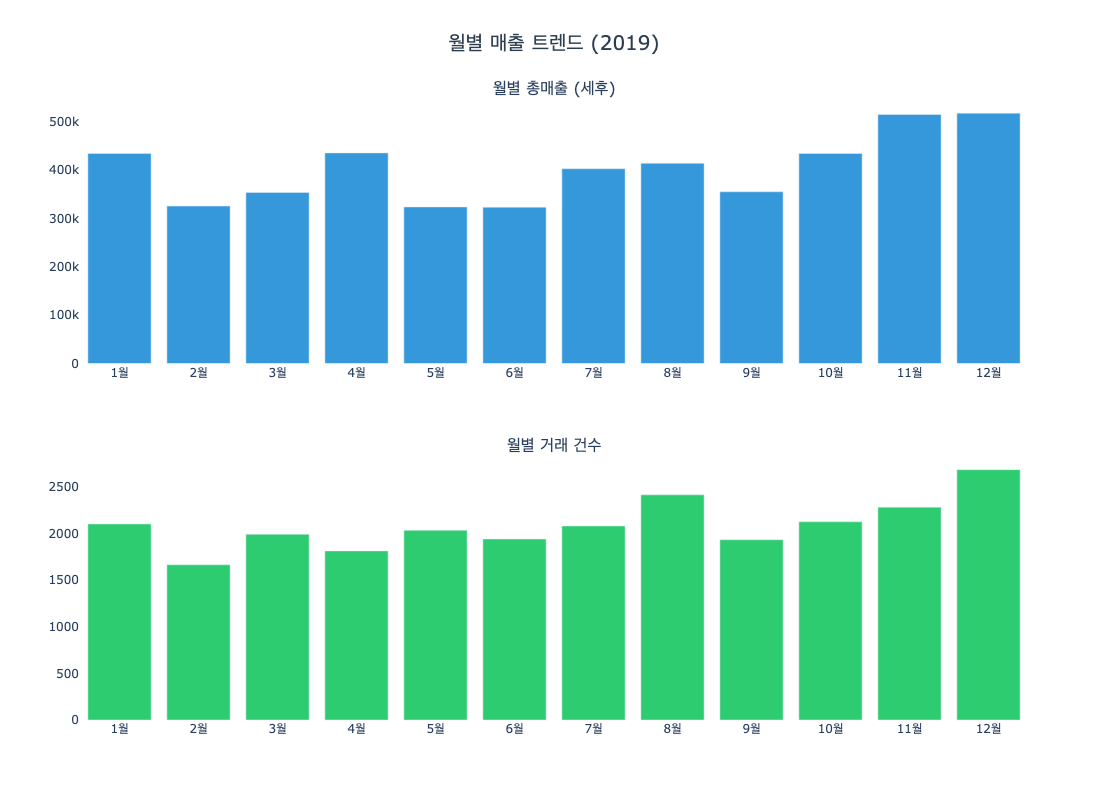

In [8]:
fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['월별 총매출 (세후)', '월별 거래 건수'],
    vertical_spacing=0.15
)

fig.add_trace(go.Bar(
    x=monthly['월'], y=monthly['총매출'],
    marker_color='#3498db', name='총매출'
), row=1, col=1)

fig.add_trace(go.Bar(
    x=monthly['월'], y=monthly['거래건수'],
    marker_color='#2ecc71', name='거래건수'
), row=2, col=1)

fig.update_layout(
    title=dict(text='월별 매출 트렌드 (2019)', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    showlegend=False,
    height=800
)

fig.update_xaxes(tickvals=list(range(1, 13)),
                 ticktext=['1월','2월','3월','4월','5월','6월',
                           '7월','8월','9월','10월','11월','12월'])

fig.show()

---
## 3. 카테고리별 분석

In [9]:
cat = run('category_sales')
cat

,제품카테고리,총매출,거래건수,평균단가
0,Nest-USA,2622006.0,11626,124.33
1,Apparel,650959.0,8129,19.79
2,Nest,504573.0,1974,194.22
3,Office,283500.0,3526,3.77
4,Drinkware,222492.0,2524,10.70
5,Bags,167982.0,1545,29.83
6,Notebooks & Journals,106610.0,620,11.76
7,Lifestyle,82038.0,1712,3.86
8,Nest-Canada,73343.0,258,157.24
9,Headgear,50398.0,674,15.88


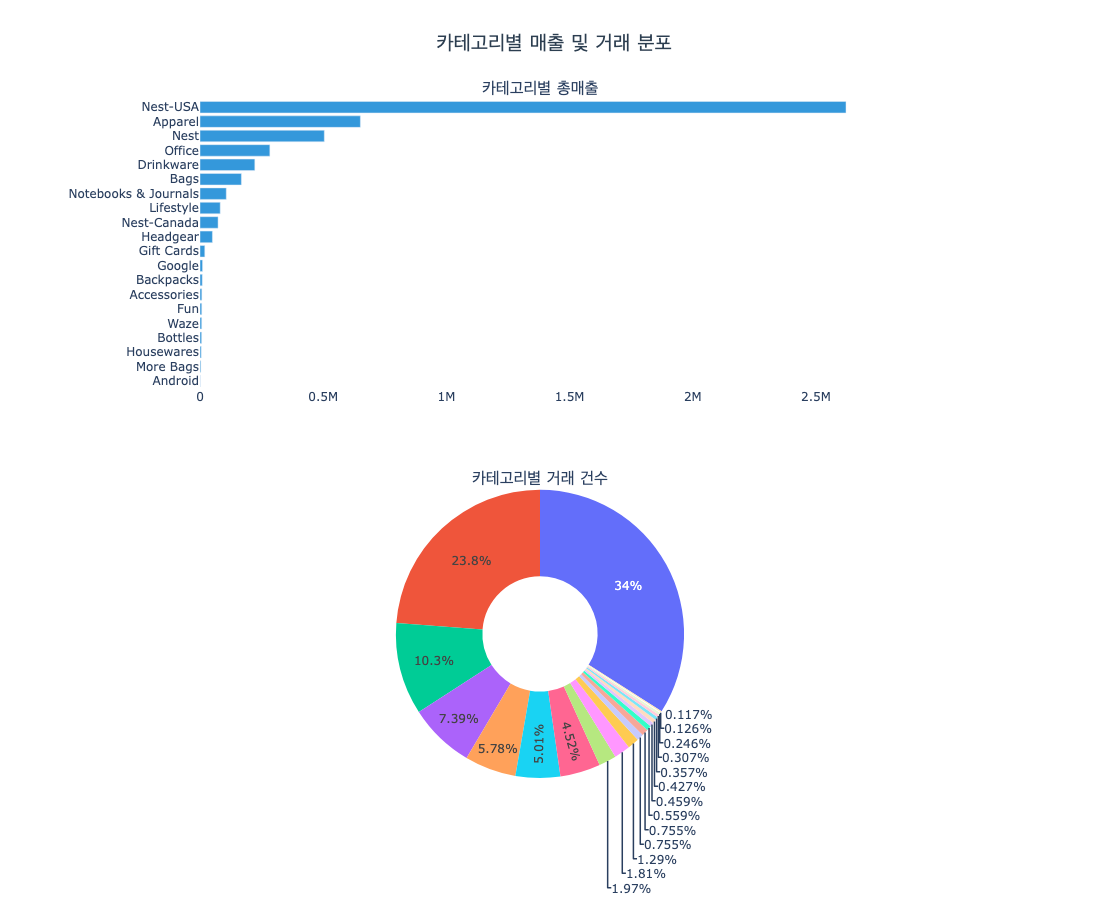

In [10]:
cat = cat.sort_values('총매출', ascending=True) 

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['카테고리별 총매출', '카테고리별 거래 건수'],
    specs=[[{'type': 'bar'}], [{'type': 'pie'}]],
    vertical_spacing=0.15
)

fig.add_trace(go.Bar(
    x=cat['총매출'], y=cat['제품카테고리'],
    orientation='h', marker_color='#3498db', name='총매출'
), row=1, col=1)

fig.add_trace(go.Pie(
    labels=cat['제품카테고리'], values=cat['거래건수'],
    hole=0.4, name='거래건수'
), row=2, col=1)

fig.update_layout(
    title=dict(text='카테고리별 매출 및 거래 분포', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    showlegend=False,
    height=900
)

fig.show()

In [11]:
# 인기 기준은 거래량 순으로 판단
product_top = run('category_top_products')
top_cats = product_top['제품카테고리'].unique().tolist()
product_top

,제품카테고리,제품ID,거래건수,총매출
0,Apparel,Product_0922,546,22812.0
1,Apparel,Product_0228,216,2837.0
2,Apparel,Product_0206,186,2933.0
3,Apparel,Product_1137,182,12026.0
4,Apparel,Product_0295,160,7712.0
5,Drinkware,Product_0880,583,29480.0
6,Drinkware,Product_0892,408,36695.0
7,Drinkware,Product_0894,319,13661.0
8,Drinkware,Product_0900,315,14739.0
9,Drinkware,Product_0908,292,8066.0


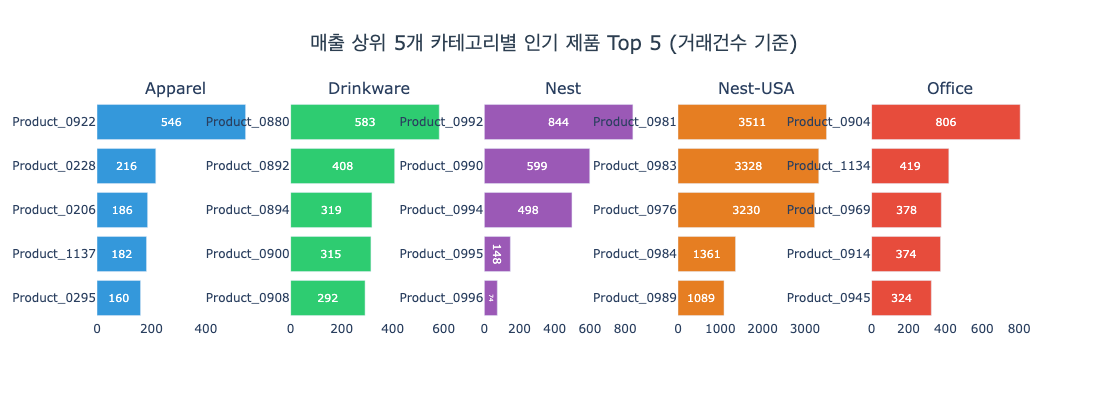

In [12]:
fig = make_subplots(
    rows=1, cols=5,
    subplot_titles=top_cats,
    shared_yaxes=False
)

colors = ['#3498db', '#2ecc71', '#9b59b6', '#e67e22', '#e74c3c']

for i, cat_name in enumerate(top_cats):
    data = product_top[product_top['제품카테고리'] == cat_name].sort_values('거래건수')
    fig.add_trace(go.Bar(
        x=data['거래건수'],
        y=data['제품ID'],
        orientation='h',
        marker_color=colors[i],
        name=cat_name,
        text=data['거래건수'],
        textposition='inside',
        insidetextanchor='middle',
        textfont=dict(size=11, color='white')
    ), row=1, col=i+1)

fig.update_layout(
    title=dict(text='매출 상위 5개 카테고리별 인기 제품 Top 5 (거래건수 기준)',
               x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    showlegend=False,
    height=400,
    width=1500
)

fig.show()

---
## 4. 고객 인구통계 분석

In [13]:
total_customers = df['고객ID'].nunique()
print(f"전체 고유 고객 수: {total_customers:,}명")

전체 고유 고객 수: 1,468명


In [14]:
gender = run('gender_sales')
gender

,성별,총매출,고객수,평균구매액
0,남,1825155.0,534,3417.89
1,여,3014947.0,934,3227.99


In [15]:
region = run('region_sales')
region

,고객지역,총매출,고객수
0,Chicago,1683160.0,456
1,California,1495425.0,464
2,New York,969922.0,324
3,New Jersey,424941.0,149
4,Washington DC,266655.0,75


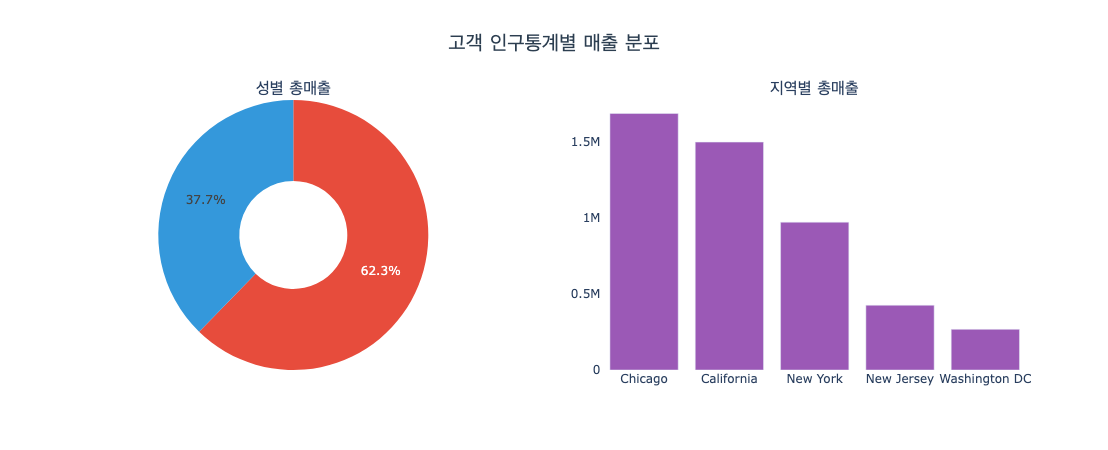

In [16]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['성별 총매출', '지역별 총매출'],
    specs=[[{'type': 'pie'}, {'type': 'bar'}]]
)

fig.add_trace(go.Pie(
    labels=gender['성별'], values=gender['총매출'],
    hole=0.4, name='성별',
    marker=dict(colors=['#3498db', '#e74c3c'])
), row=1, col=1)

fig.add_trace(go.Bar(
    x=region['고객지역'], y=region['총매출'],
    marker_color='#9b59b6', name='지역별'
), row=1, col=2)

fig.update_layout(
    title=dict(text='고객 인구통계별 매출 분포', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    showlegend=False,
    height=450
)

fig.show()

In [17]:
tenure = run('tenure_behavior')
tenure

,가입기간_구간,고객수,평균구매액,고객당_평균구매금액,쿠폰사용률,쿠폰사용고객비율,구매빈도
0,0~12개월,327,91.93,3185.06,33.2,93.9,17.65
1,13~24개월,361,88.44,2984.99,33.8,92.8,16.95
2,25개월 이상,780,92.52,3488.47,33.8,93.8,18.89


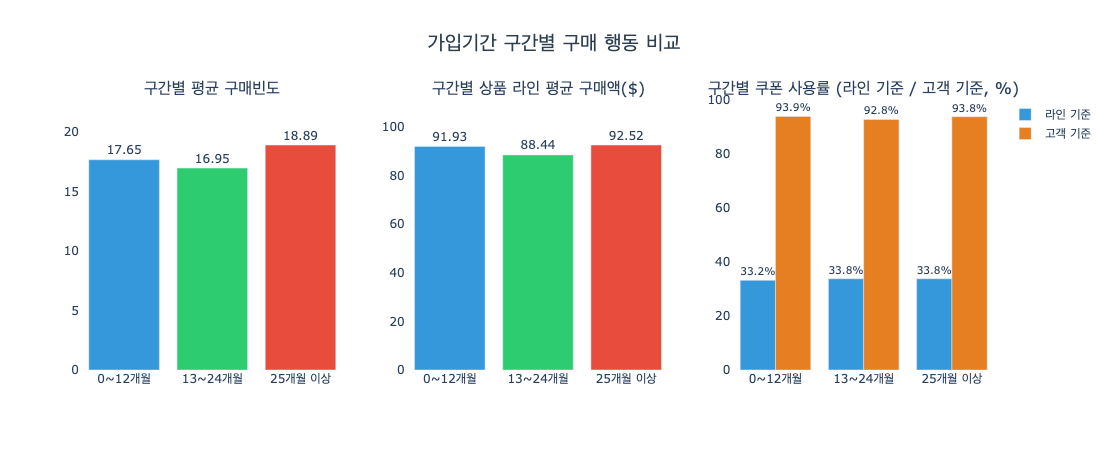

In [18]:
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=['구간별 평균 구매빈도', '구간별 상품 라인 평균 구매액($)', '구간별 쿠폰 사용률 (라인 기준 / 고객 기준, %)']
)

color = ['#3498db', '#2ecc71', '#e74c3c']

fig.add_trace(go.Bar(
    x=tenure['가입기간_구간'], y=tenure['구매빈도'],
    marker_color=color, text=tenure['구매빈도'], textposition='outside',
    showlegend=False
), row=1, col=1)

fig.add_trace(go.Bar(
    x=tenure['가입기간_구간'], y=tenure['평균구매액'],
    marker_color=color, text=tenure['평균구매액'], textposition='outside',
    showlegend=False
), row=1, col=2)

fig.add_trace(go.Bar(
    x=tenure['가입기간_구간'], y=tenure['쿠폰사용률'],
    marker_color='#3498db', name='라인 기준',
    text=tenure['쿠폰사용률'].astype(str) + '%', textposition='outside'
), row=1, col=3)

fig.add_trace(go.Bar(
    x=tenure['가입기간_구간'], y=tenure['쿠폰사용고객비율'],
    marker_color='#e67e22', name='고객 기준',
    text=tenure['쿠폰사용고객비율'].astype(str) + '%', textposition='outside'
), row=1, col=3)

fig.update_layout(
    title=dict(text='가입기간 구간별 구매 행동 비교', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    barmode='group',
    legend=dict(orientation='v', x=1.01, y=1),
    height=450
)

fig.update_yaxes(range=[0, tenure['구매빈도'].max() * 1.2], row=1, col=1)
fig.update_yaxes(range=[0, tenure['평균구매액'].max() * 1.2], row=1, col=2)
fig.update_yaxes(range=[0, 100], row=1, col=3)

fig.show()

### 고객별 거래 건수 분포

1년간 고객 1인당 거래 건수의 분포를 확인한다.

In [19]:
# 고객별 거래 건수 분포
purchase_freq = run('purchase_frequency')
purchase_freq.describe().round(1)

,거래건수
count,1468.0
mean,18.1
std,25.0
min,1.0
25%,5.0
50%,11.0
75%,23.0
max,328.0


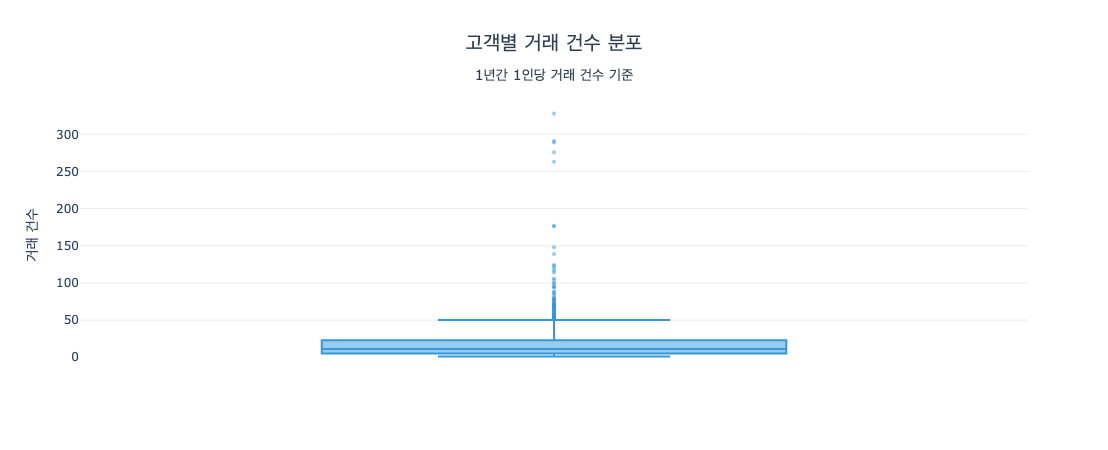

In [20]:
fig = go.Figure(go.Box(
    y=purchase_freq["거래건수"],
    boxpoints="outliers",
    marker=dict(color="#3498db", size=4, opacity=0.5),
    line=dict(color="#3498db"),
    name=""
))

fig.update_layout(
    title=dict(
        text="고객별 거래 건수 분포<br><sub>1년간 1인당 거래 건수 기준</sub>",
        x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50")
    ),
    yaxis_title="거래 건수",
    plot_bgcolor="white",
    xaxis=dict(showticklabels=False),
    yaxis=dict(gridcolor="#ececec"),
    height=450
)
fig.show()

- 중앙값 **11건**, 평균 **18.1건** — 평균이 중앙값보다 높아 소수의 헤비유저가 평균을 끌어올리는 우편향 분포
- **75%의 고객이 23건 이하**로 구매 빈도가 낮은 고객이 대부분을 차지
- 최댓값 **327건**으로 극단적인 헤비유저가 존재하며, 이상치 점들이 다수 분포

### 고객별 재방문 횟수 분포

거래 건수가 아닌 **구매일 수 기준**으로 재방문 횟수를 집계한다.  
같은 날 여러 번 구매한 경우 1회 방문으로 처리한다.

In [21]:
revisit_freq = run('revisit_frequency')
revisit_freq.describe().round(1)

,재방문횟수
count,1468.0
mean,1.2
std,2.2
min,0.0
25%,0.0
50%,0.5
75%,2.0
max,33.0


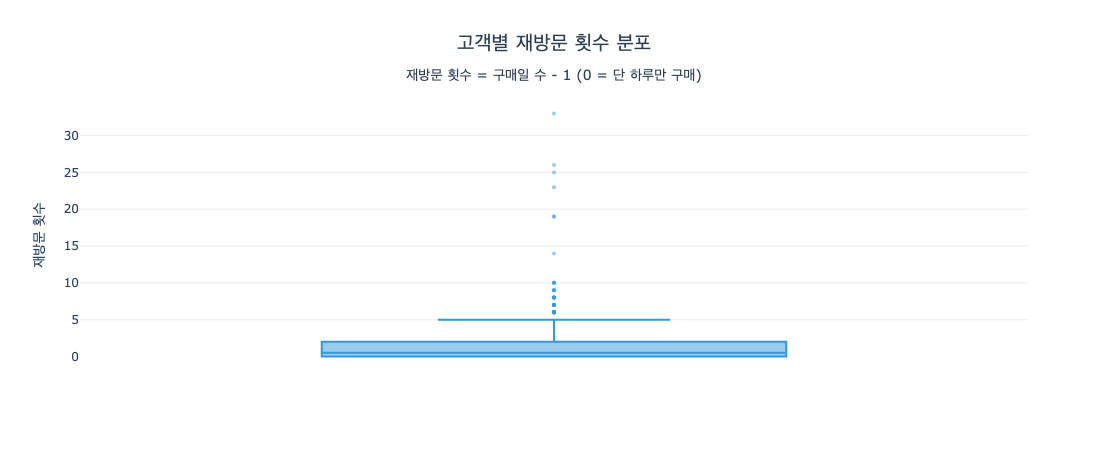

In [22]:
fig = go.Figure(go.Box(
    y=revisit_freq["재방문횟수"],
    boxpoints="outliers",
    marker=dict(color="#3498db", size=4, opacity=0.5),
    line=dict(color="#3498db"),
    name=""
))

fig.update_layout(
    title=dict(
        text="고객별 재방문 횟수 분포<br><sub>재방문 횟수 = 구매일 수 - 1 (0 = 단 하루만 구매)</sub>",
        x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50")
    ),
    yaxis_title="재방문 횟수",
    plot_bgcolor="white",
    xaxis=dict(showticklabels=False),
    yaxis=dict(gridcolor="#ececec"),
    height=450
)
fig.show()

### 성별 구매 패턴

성별로 구매금액 중앙값을 비교하고, 각 성별에서 가장 자주 구매한 카테고리를 확인한다.

In [23]:
# 성별 구매금액 통계 (중앙값·평균)
gender_stats = (
    df.groupby("성별")["세후금액"]
    .agg(["mean", "median"])
    .round(2)
    .rename(columns={"mean": "평균", "median": "중앙값"})
    .reset_index()
)

# 성별 × 카테고리 중앙값
gender_cat_median = (
    df.groupby(["성별", "제품카테고리"])["세후금액"]
    .median()
    .round(2)
    .unstack("성별")
    .reset_index()
    .rename(columns={"남": "남성_중앙값", "여": "여성_중앙값"})
)


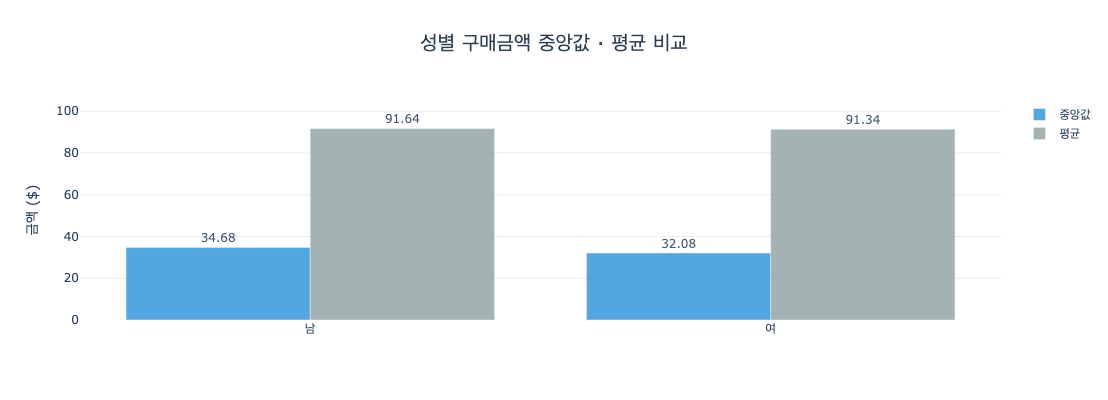

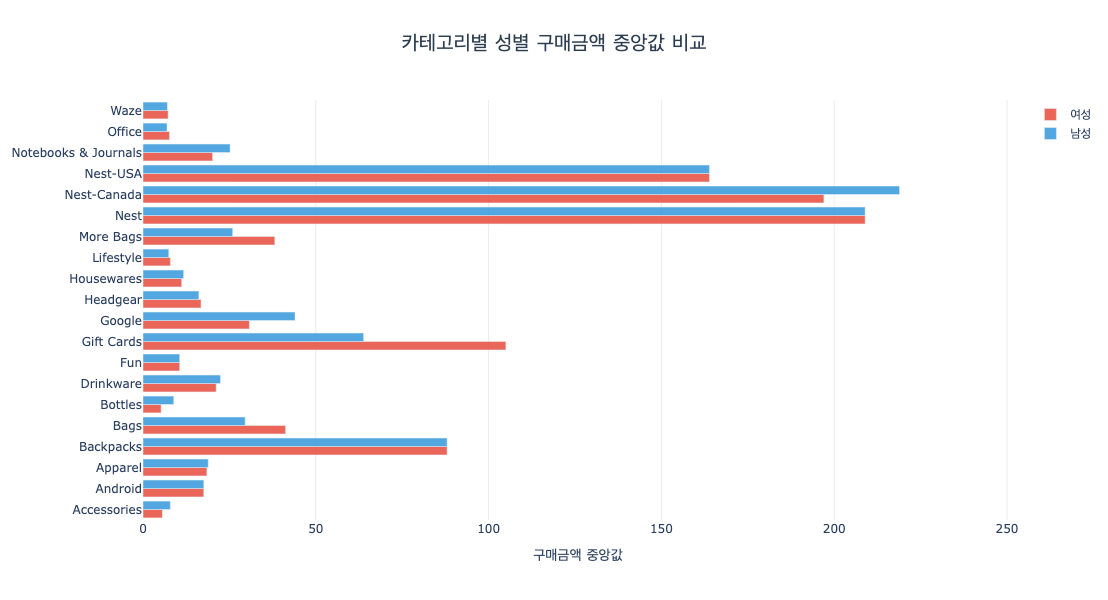

In [24]:
# ── 차트 1: 성별 구매금액 중앙값 · 평균 비교 ──
y_max1 = gender_stats[["중앙값", "평균"]].max().max() * 1.15

fig1 = go.Figure()
for metric, color in [("중앙값", "#3498db"), ("평균", "#95a5a6")]:
    fig1.add_trace(go.Bar(
        x=gender_stats["성별"],
        y=gender_stats[metric],
        name=metric,
        marker_color=color,
        text=gender_stats[metric],
        textposition="outside",
        opacity=0.85
    ))
    
fig1.update_layout(
    title=dict(text="성별 구매금액 중앙값 · 평균 비교",
               x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50")),
    barmode="group",
    yaxis_title="금액 ($)",
    plot_bgcolor="white",
    yaxis=dict(gridcolor="#ececec", range=[0, y_max1]),
    height=400
)

fig1.show()

# ── 차트 2: 카테고리별 성별 중앙값 비교 ──
cats = gender_cat_median["제품카테고리"].tolist()
x_max2 = gender_cat_median[["남성_중앙값", "여성_중앙값"]].max().max() * 1.15

fig2 = go.Figure()
fig2.add_trace(go.Bar(
    y=cats, x=gender_cat_median["여성_중앙값"],
    name="여성", orientation="h",
    marker_color="#e74c3c", opacity=0.85
))

fig2.add_trace(go.Bar(
    y=cats, x=gender_cat_median["남성_중앙값"],
    name="남성", orientation="h",
    marker_color="#3498db", opacity=0.85
))

fig2.update_layout(
    title=dict(text="카테고리별 성별 구매금액 중앙값 비교",
               x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50")),
    barmode="group",
    xaxis_title="구매금액 중앙값",
    plot_bgcolor="white",
    xaxis=dict(gridcolor="#ececec", range=[0, x_max2]),
    height=600
)
fig2.show()


---
## 5. 쿠폰/할인 효과 분석

> **집계 단위**: 상품 라인(원본 데이터의 한 행 = 한 거래에서 구매한 상품 한 종류). 쿠폰 상태가 같은 거래 안에서도 상품마다 다를 수 있어 거래 단위로 묶지 않았다. 거래 단위 항목인 배송료는 라인 단위 평균에 배부할 수 없으므로 이 섹션의 금액 지표에는 포함되지 않는다.
>
> **쿠폰 상태**: 원본 `쿠폰상태` 컬럼의 세 값을 그대로 사용한다.
> - `Used` — 쿠폰이 실제 적용된 상품 라인
> - `Clicked` — 쿠폰이 노출·클릭됐으나 적용되지 않은 상품 라인
> - `Not Used` — 쿠폰과 무관한 상품 라인
>
> 단, `Used` 중 Discount 테이블에 할인 정보가 없는 카테고리(Fun·Google, 81행)는 실제 할인이 적용되지 않으므로 할인율별 분석에서 제외된다. 따라서 쿠폰 상태별 `Used` 라인 수(17,904)와 할인율별 합계(17,823)가 81행 차이 난다.
>
> **금액 3단계**: `세전`(할인·세금 전 상품금액) → `할인 후(세전)`(할인 적용, 세금 전) → `할인 후(세후)`(할인·세금 모두 반영). 세 단계를 나누면 금액 변화가 할인에서 온 것인지 세금에서 온 것인지 구분된다. (단, 배송료는 거래 단위 항목이라 라인 평균에 배부할 수 없어 제외)

In [25]:
coupon = run('coupon_status')
coupon

,쿠폰상태,상품라인수,라인평균_세전,라인평균_할인후_세전,라인평균_할인후_세후,총매출
0,Used,17904,87.18,69.79,77.42,1386192.0
1,Not Used,8094,90.53,90.53,100.53,813723.0
2,Clicked,26926,88.29,88.29,98.05,2640187.0


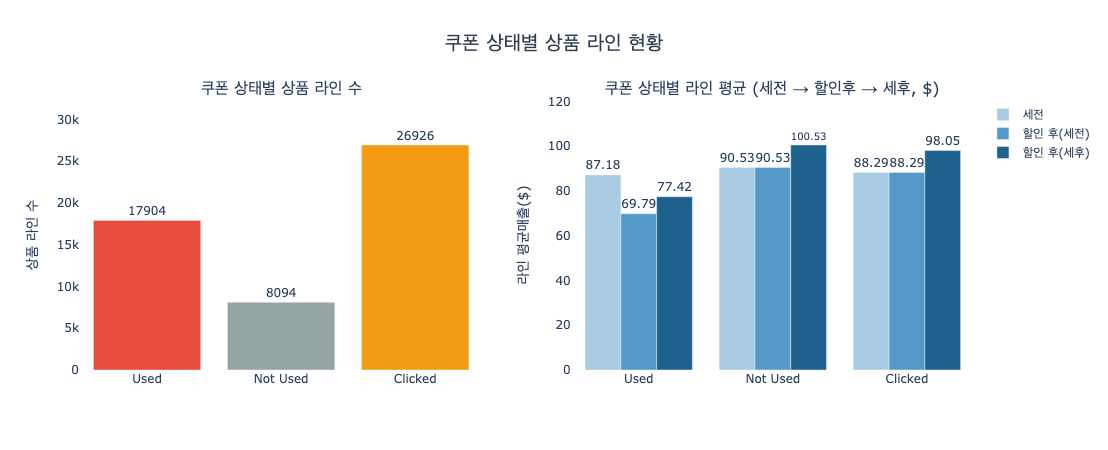

In [26]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=['쿠폰 상태별 상품 라인 수', '쿠폰 상태별 라인 평균 (세전 → 할인후 → 세후, $)']
)

colors = {'Used': '#e74c3c', 'Clicked': '#f39c12', 'Not Used': '#95a5a6'}
c_colors = [colors[s] for s in coupon['쿠폰상태']]

# 좌: 상품 라인 수
fig.add_trace(go.Bar(
    x=coupon['쿠폰상태'], y=coupon['상품라인수'],
    marker_color=c_colors,
    text=coupon['상품라인수'],
    textposition='outside',
    showlegend=False
), row=1, col=1)

# 우: 3단계 라인 평균
stages = [('세전', '라인평균_세전', '#a9cce3'),
          ('할인 후(세전)', '라인평균_할인후_세전', '#5499c7'),
          ('할인 후(세후)', '라인평균_할인후_세후', '#1f618d')]
for name, col, hexc in stages:
    fig.add_trace(go.Bar(
        x=coupon['쿠폰상태'], y=coupon[col].round(2),
        marker_color=hexc, name=name,
        text=coupon[col].round(2), textposition='outside'
    ), row=1, col=2)

fig.update_layout(
    title=dict(text='쿠폰 상태별 상품 라인 현황', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    barmode='group',
    legend=dict(orientation='v', x=1.01, y=1),
    height=450
)

stage_max = coupon[['라인평균_세전', '라인평균_할인후_세전', '라인평균_할인후_세후']].max().max()
fig.update_yaxes(title_text='상품 라인 수', range=[0, coupon['상품라인수'].max() * 1.2], row=1, col=1)
fig.update_yaxes(title_text='라인 평균매출($)', range=[0, stage_max * 1.2], row=1, col=2)

fig.show()

In [27]:
discount_grp = run('discount_rate')
discount_grp

,할인율,상품라인수,라인평균_세전,라인평균_할인후_세전,라인평균_할인후_세후
0,10.0,5949,87.49,78.74,87.55
1,20.0,6018,85.07,68.05,75.26
2,30.0,5856,89.31,62.51,69.38


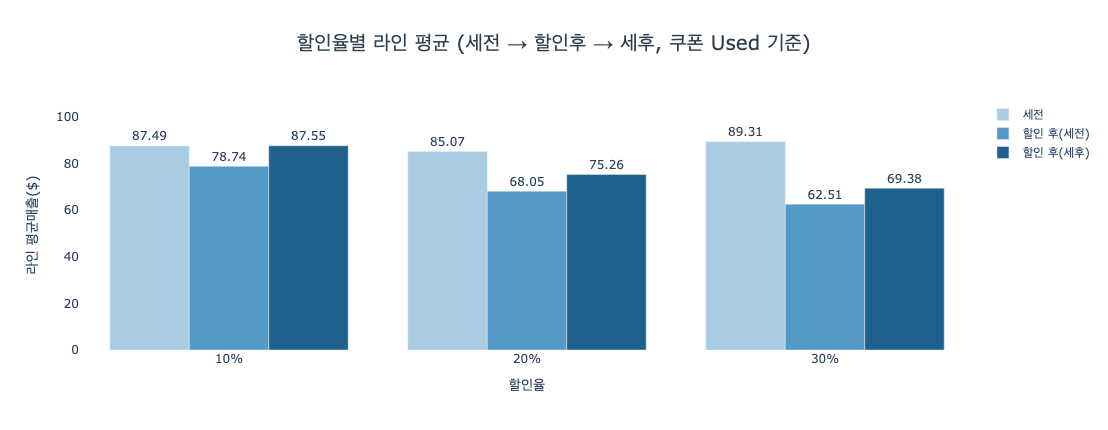

In [28]:
fig = go.Figure()

x_labels = discount_grp['할인율'].astype(int).astype(str) + '%'

stages = [('세전', '라인평균_세전', '#a9cce3'),
          ('할인 후(세전)', '라인평균_할인후_세전', '#5499c7'),
          ('할인 후(세후)', '라인평균_할인후_세후', '#1f618d')]
for name, col, hexc in stages:
    fig.add_trace(go.Bar(
        x=x_labels, y=discount_grp[col].round(2),
        marker_color=hexc, name=name,
        text=discount_grp[col].round(2), textposition='outside'
    ))

fig.update_layout(
    title=dict(text='할인율별 라인 평균 (세전 → 할인후 → 세후, 쿠폰 Used 기준)', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    xaxis_title='할인율',
    yaxis_title='라인 평균매출($)',
    plot_bgcolor='white',
    barmode='group',
    legend=dict(orientation='v', x=1.01, y=1),
    width=640,
    height=430
)

ymax = discount_grp[['라인평균_세전', '라인평균_할인후_세전', '라인평균_할인후_세후']].max().max()
fig.update_yaxes(range=[0, ymax * 1.2])

fig.show()

> 세 단계를 나누면 할인 효과와 세금 효과가 분리된다. 세금은 전 구간에서 약 11% 수준으로 일정하므로, 단계 간 차이는 할인율에서 발생한다.
>
> 할인율은 월 + 카테고리 조합으로 결정되므로 할인율 그룹은 월 그룹과 대응한다 (10% = 1·4·7·10월, 20% = 2·5·8·11월, 30% = 3·6·9·12월). 따라서 할인율별 비교는 계절 효과와 완전히 분리되지 않는다.

---
## 6. 마케팅 비용 분석

In [29]:
marketing_monthly = run('marketing_monthly')
marketing_monthly['총마케팅비용'] = marketing_monthly['오프라인비용'] + marketing_monthly['온라인비용']
marketing_monthly['매출_광고비_배수'] = (
    marketing_monthly['총매출'] / marketing_monthly['총마케팅비용']
).round(2)
marketing_monthly


,월,총매출,오프라인비용,온라인비용,매출_광고비_배수,총마케팅비용
0,1,434840.0,96600.0,58329.0,2.81,154929.0
1,2,325906.0,81300.0,55808.0,2.38,137108.0
2,3,354212.0,73500.0,48750.0,2.90,122250.0
3,4,435947.0,96000.0,61027.0,2.78,157027.0
4,5,324075.0,65500.0,52760.0,2.74,118260.0
5,6,323446.0,80500.0,53818.0,2.41,134318.0
6,7,403135.0,67500.0,52718.0,3.35,120218.0
7,8,414591.0,85500.0,57404.0,2.90,142904.0
8,9,355472.0,83000.0,52515.0,2.62,135515.0
9,10,434788.0,93500.0,57725.0,2.88,151225.0


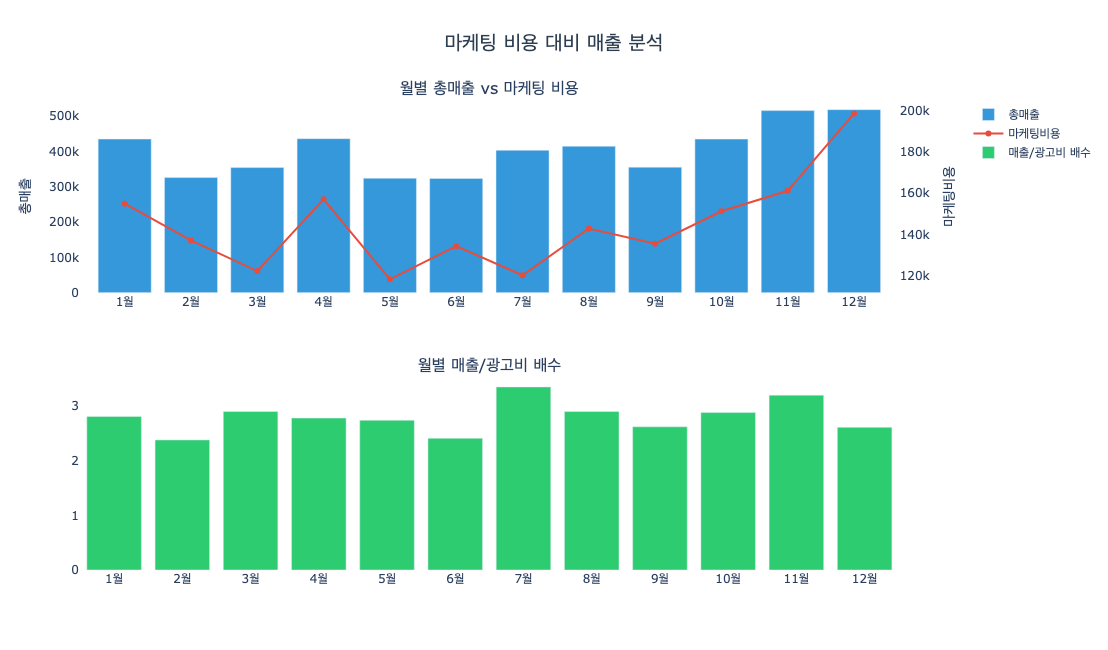

In [30]:
월_labels = []

for i in range(0, 12):
    월_labels.append(str(i+1) + '월')

fig = make_subplots(
    rows=2, cols=1,
    subplot_titles=['월별 총매출 vs 마케팅 비용', '월별 매출/광고비 배수'],
    specs=[[{"secondary_y": True}], [{"secondary_y": False}]],
    vertical_spacing=0.18
)

fig.add_trace(go.Bar(
    x=marketing_monthly['월'], y=marketing_monthly['총매출'],
    name='총매출', marker_color='#3498db'
), row=1, col=1, secondary_y=False)

fig.add_trace(go.Scatter(
    x=marketing_monthly['월'], y=marketing_monthly['총마케팅비용'],
    name='마케팅비용', mode='lines+markers',
    line=dict(color='#e74c3c', width=2), marker=dict(size=6)
), row=1, col=1, secondary_y=True)

fig.add_trace(go.Bar(
    x=marketing_monthly['월'], y=marketing_monthly['매출_광고비_배수'],
    name='매출/광고비 배수', marker_color='#2ecc71'
), row=2, col=1)

fig.update_yaxes(title_text='총매출', secondary_y=False, row=1, col=1)
fig.update_yaxes(title_text='마케팅비용', secondary_y=True, row=1, col=1)

fig.update_layout(
    title=dict(text='마케팅 비용 대비 매출 분석', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white',
    height=650,
    showlegend=True
)

fig.update_xaxes(tickvals=list(range(1, 13)), ticktext=월_labels)
fig.show()

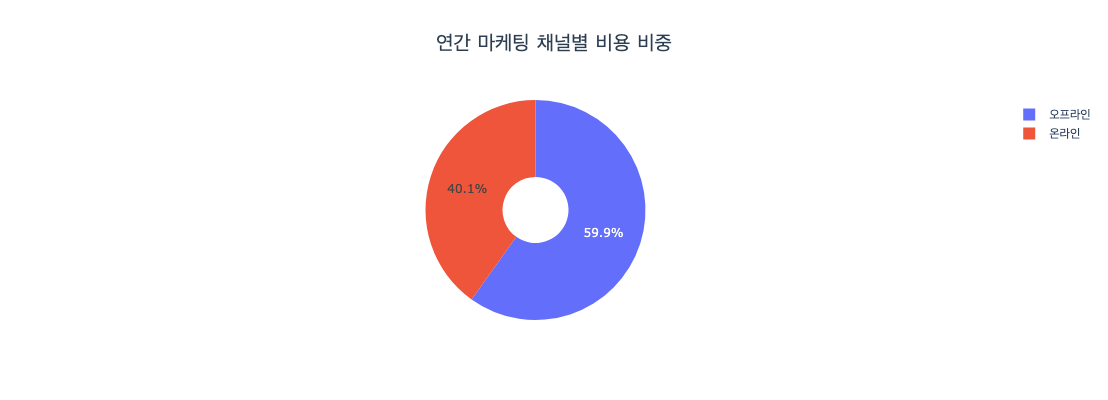

In [31]:
daily = df.drop_duplicates('거래날짜')[['거래날짜', '오프라인비용', '온라인비용']]
offline_total = daily['오프라인비용'].sum()
online_total = daily['온라인비용'].sum()

fig = go.Figure(go.Pie(
    labels=['오프라인', '온라인'],
    values=[offline_total, online_total],
    hole=0.3
))

fig.update_layout(
    title=dict(text='연간 마케팅 채널별 비용 비중', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    height=400
)

fig.show()

In [32]:
corr = marketing_monthly[['총매출', '온라인비용', '오프라인비용']].corr().round(2)
corr

,총매출,온라인비용,오프라인비용
총매출,1.00,0.86,0.77
온라인비용,0.86,1.00,0.88
오프라인비용,0.77,0.88,1.00


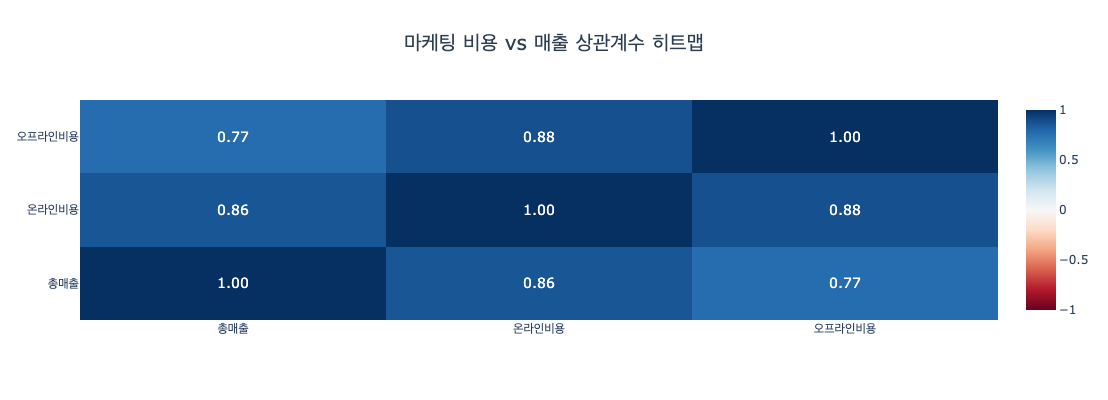

In [33]:
labels = ['총매출', '온라인비용', '오프라인비용']
z = corr.values

fig = go.Figure(go.Heatmap(
    z=z,
    x=labels,
    y=labels,
    colorscale='RdBu',
    zmin=-1, zmax=1,
    text=[[f'{v:.2f}' for v in row] for row in z],
    texttemplate='%{text}',
    textfont=dict(size=14),
    showscale=True
))

fig.update_layout(
    title=dict(text='마케팅 비용 vs 매출 상관계수 히트맵', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    height=400,
    width=500
)
fig.show()

### 마케팅비와 후속 14일 ARPPU의 탐색적 연관성

광고 집행일을 포함한 정확히 14일간의 매출과 구매 고객을 집계한다. 모든 날짜에
마케팅비가 존재하고 윈도우가 서로 겹치므로, 아래 분석은 캠페인 효과나 채널별
인과 효과가 아니라 **비용과 후속 매출의 탐색적 연관성**만 보여준다.

2019-12-19 이후 집행일은 14일 관측창이 연도를 벗어나므로 제외한다.


In [34]:
# 광고일 포함 14일 윈도우: 시작일 ~ 시작일+13일
mar_dates = (
    df[['거래날짜', '오프라인비용', '온라인비용']]
    .drop_duplicates('거래날짜')
    .query("거래날짜 <= '2019-12-18'")
    .reset_index(drop=True)
)

rows = []
for _, row in mar_dates.iterrows():
    start = row['거래날짜']
    end = start + pd.Timedelta(days=13)
    window = df[(df['거래날짜'] >= start) & (df['거래날짜'] <= end)]
    rows.append({
        '날짜': start,
        '오프라인비용': row['오프라인비용'],
        '온라인비용': row['온라인비용'],
        '총마케팅비용': row['오프라인비용'] + row['온라인비용'],
        '+14일_누적매출': window['세후금액'].sum(),
        '+14일_누적고객': window['고객ID'].nunique(),
    })

daily_mkt = pd.DataFrame(rows)
print(f"분석 대상 집행일: {len(daily_mkt)}일 (2019-01-01 ~ 2019-12-18)")


분석 대상 집행일: 352일 (2019-01-01 ~ 2019-12-18)


In [35]:
daily_mkt.head()

,날짜,오프라인비용,온라인비용,총마케팅비용,+14일_누적매출,+14일_누적고객
0,2019-01-01,4500,2424.50,6924.50,195605.23,88
1,2019-01-02,4500,3480.36,7980.36,196742.18,88
2,2019-01-03,4500,1576.38,6076.38,194894.96,86
3,2019-01-04,4500,2928.55,7428.55,188513.67,86
4,2019-01-05,4500,4055.30,8555.30,192377.83,90


In [36]:
daily_mkt['ARPPU'] = daily_mkt['+14일_누적매출'] / daily_mkt['+14일_누적고객']
daily_mkt[['날짜', '+14일_누적고객', '+14일_누적매출', 'ARPPU']].head()

,날짜,+14일_누적고객,+14일_누적매출,ARPPU
0,2019-01-01,88,195605.23,2222.786705
1,2019-01-02,88,196742.18,2235.706591
2,2019-01-03,86,194894.96,2266.220465
3,2019-01-04,86,188513.67,2192.019419
4,2019-01-05,90,192377.83,2137.531444


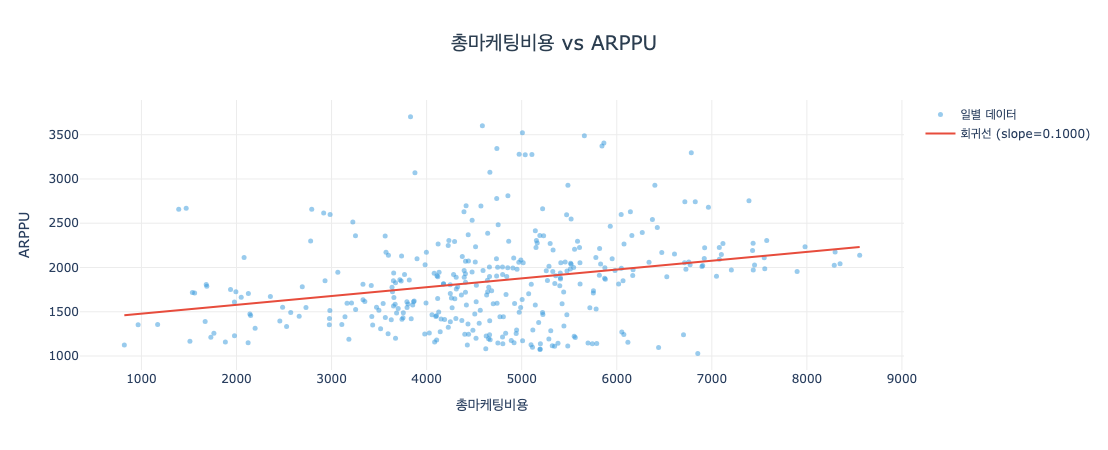

In [37]:
from scipy import stats

slope_total, intercept_total, *_ = stats.linregress(daily_mkt['총마케팅비용'], daily_mkt['ARPPU'])
x_line = np.linspace(daily_mkt['총마케팅비용'].min(), daily_mkt['총마케팅비용'].max(), 100)
y_line = slope_total * x_line + intercept_total

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=daily_mkt['총마케팅비용'], y=daily_mkt['ARPPU'],
    mode='markers', marker=dict(color='#3498db', size=5, opacity=0.5),
    name='일별 데이터'
))
fig.add_trace(go.Scatter(
    x=x_line, y=y_line,
    mode='lines', line=dict(color='#e74c3c', width=2),
    name=f'회귀선 (slope={slope_total:.4f})'
))
fig.update_layout(
    title=dict(text='총마케팅비용 vs ARPPU', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    xaxis_title='총마케팅비용', yaxis_title='ARPPU',
    plot_bgcolor='white', width=900, height=450
)
fig.update_xaxes(gridcolor='#ececec')
fig.update_yaxes(gridcolor='#ececec')
fig.show()

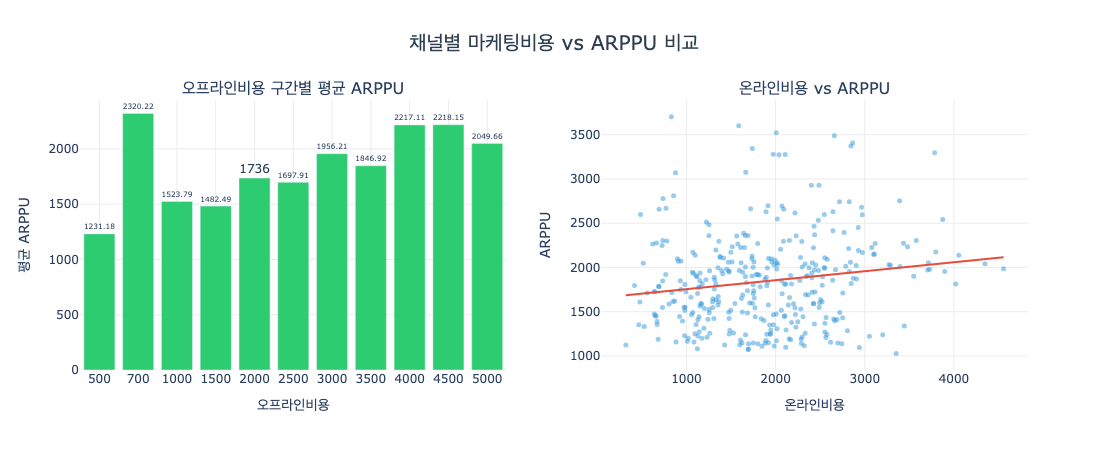

In [38]:
# 오프라인: 비용 구간별 평균 ARPPU
offline_avg = daily_mkt.groupby('오프라인비용')['ARPPU'].mean().reset_index()
offline_avg['ARPPU'] = offline_avg['ARPPU'].round(2)

# 온라인: 회귀선
slope_online, intercept_online, *_ = stats.linregress(daily_mkt['온라인비용'], daily_mkt['ARPPU'])
x_on = np.linspace(daily_mkt['온라인비용'].min(), daily_mkt['온라인비용'].max(), 100)
y_on = slope_online * x_on + intercept_online

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[
        '오프라인비용 구간별 평균 ARPPU',
        f'온라인비용 vs ARPPU'
    ]
)

fig.add_trace(go.Bar(
    x=offline_avg['오프라인비용'].astype(str),
    y=offline_avg['ARPPU'],
    marker_color='#2ecc71',
    text=offline_avg['ARPPU'],
    textposition='outside',
    name='오프라인'
), row=1, col=1)

fig.add_trace(go.Scatter(
    x=daily_mkt['온라인비용'], y=daily_mkt['ARPPU'],
    mode='markers', marker=dict(color='#3498db', size=5, opacity=0.5),
    name='온라인 데이터'
), row=1, col=2)
fig.add_trace(go.Scatter(
    x=x_on, y=y_on,
    mode='lines', line=dict(color='#e74c3c', width=2),
    name='회귀선'
), row=1, col=2)

fig.update_layout(
    title=dict(text='채널별 마케팅비용 vs ARPPU 비교', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white', height=450, showlegend=False
)
fig.update_xaxes(title_text='오프라인비용', row=1, col=1, gridcolor='#ececec')
fig.update_yaxes(title_text='평균 ARPPU', row=1, col=1, gridcolor='#ececec')
fig.update_xaxes(title_text='온라인비용', row=1, col=2, gridcolor='#ececec')
fig.update_yaxes(title_text='ARPPU', row=1, col=2, gridcolor='#ececec')
fig.show()

#### 채널별 연관성 비교 시 주의

온라인·오프라인 비용의 단위와 변동폭이 다르고 두 비용이 함께 움직이므로 원계수의
크기를 비교해 어느 채널이 더 효과적인지 판정하지 않는다. 아래 표준화 회귀계수는
같은 모형 안에서 방향과 상대적 연관성을 탐색하는 참고값이다.


In [39]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

X = daily_mkt[['온라인비용', '오프라인비용']]
y = daily_mkt['ARPPU']
X_standardized = StandardScaler().fit_transform(X)
model = LinearRegression().fit(X_standardized, y)

coef = pd.Series(model.coef_, index=X.columns, name='표준화_연관계수')
print(coef.round(3))
print(f'설명력 R²: {model.score(X_standardized, y):.3f}')
print('※ 중첩 관측창·계절성·동시 집행이 있어 채널 인과효과로 해석하지 않는다.')


온라인비용      35.625
오프라인비용    134.012
Name: 표준화_연관계수, dtype: float64
설명력 R²: 0.083
※ 중첩 관측창·계절성·동시 집행이 있어 채널 인과효과로 해석하지 않는다.


---
## 7. 지역별 구매 패턴

고객지역별로 고객 수, 평균 구매횟수, 평균구매금액을 비교한다.  
고객 수와 구매금액이 모두 높은 지역은 집중 투자 우선순위가 명확한 핵심 타겟이다.

In [40]:
cust_summary = run('customer_summary')
cust_summary.head(3)

,고객ID,구매횟수,총구매금액,평균구매금액
0,USER_0000,1,25.0,24.98
1,USER_0001,31,15022.0,484.57
2,USER_0002,8,1492.0,186.55


In [41]:
region_summary = run('region_customer_summary')
region_summary

,고객지역,고객수,평균구매횟수,평균구매금액
0,Washington DC,75,18.89,195.36
1,New Jersey,149,15.36,179.99
2,Chicago,456,20.36,171.95
3,California,464,17.37,167.61
4,New York,324,17.24,165.82


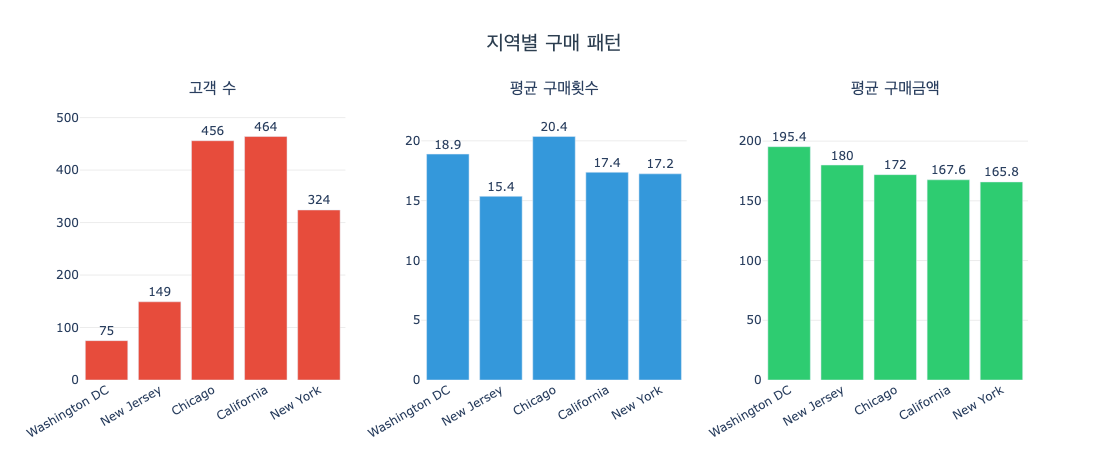

In [42]:
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=('고객 수', '평균 구매횟수', '평균 구매금액'),
    horizontal_spacing=0.08
)

cols_colors = [
    ('고객수', '#e74c3c'),
    ('평균구매횟수', '#3498db'),
    ('평균구매금액', '#2ecc71'),
]

for i, (col, color) in enumerate(cols_colors, 1):
    fig.add_trace(go.Bar(
        x=region_summary['고객지역'],
        y=region_summary[col],
        text=region_summary[col].round(1),
        textposition='outside',
        marker_color=color, 
        showlegend=False
    ), row=1, col=i)

fig.update_layout(
    title=dict(
        text='지역별 구매 패턴',
        x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')
    ),
    plot_bgcolor='white', height=460
)
for i in range(1, 4):
    fig.update_xaxes(tickangle=-30, row=1, col=i)
    fig.update_yaxes(gridcolor='#ececec', row=1, col=i)

fig.update_yaxes(range=[0, region_summary['고객수'].max() * 1.15], row=1, col=1)
fig.update_yaxes(range=[0, region_summary['평균구매횟수'].max() * 1.15], row=1, col=2)
fig.update_yaxes(range=[0, region_summary['평균구매금액'].max() * 1.2], row=1, col=3)

fig.show()

---
## 8. 요일별 구매 패턴

요일별 일평균 거래건수와 평균 거래금액을 비교한다.  
특정 요일에 구매 활동이 집중되면 마케팅 집행 주기 설정에 활용할 수 있다.

In [43]:
dow_summary = run('weekday_pattern')
dow_summary

,거래요일,일평균_거래건수,평균_거래금액
0,Mon,40.96,176.92
1,Tue,43.68,176.79
2,Wed,84.19,195.01
3,Thu,82.27,205.09
4,Fri,81.40,212.99
5,Sat,74.46,180.73
6,Sun,74.13,187.15


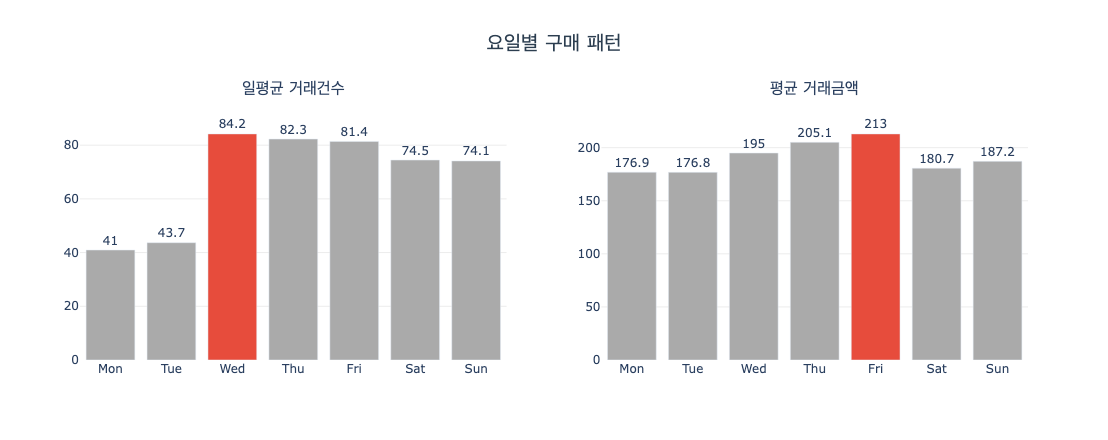

In [44]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('일평균 거래건수', '평균 거래금액'),
    horizontal_spacing=0.1
)

for i, col in enumerate(['일평균_거래건수', '평균_거래금액'], 1):
    max_day = dow_summary.loc[dow_summary[col].idxmax(), '거래요일']
    fig.add_trace(go.Bar(
        x=dow_summary['거래요일'],
        y=dow_summary[col],
        marker_color=[
            '#e74c3c' if d == max_day else '#aaaaaa'
            for d in dow_summary['거래요일']
        ],
        text=dow_summary[col].round(1),
        textposition='outside',
        showlegend=False
    ), row=1, col=i)

fig.update_layout(
    title=dict(
        text='요일별 구매 패턴',
        x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')
    ),
    plot_bgcolor='white', height=440
)
for i in range(1, 3):
    fig.update_yaxes(gridcolor='#ececec', row=1, col=i)

fig.update_yaxes(range=[0, dow_summary['일평균_거래건수'].max() * 1.15], row=1, col=1)
fig.update_yaxes(range=[0, dow_summary['평균_거래금액'].max() * 1.15], row=1, col=2)

fig.show()

---
## 9. 장바구니 분석

In [45]:
basket = run('basket_size')

cat_div = run('customer_category_diversity')

print(f"거래당 평균 아이템 수: {basket['아이템수'].mean():.2f}")
print(f"거래당 평균 카테고리 수: {basket['카테고리수'].mean():.2f}")
print(f"단일 아이템 거래 비중: {(basket['아이템수'] == 1).mean()*100:.1f}%")
print(f"\n고객별 평균 구매 카테고리 수: {cat_div['구매카테고리수'].mean():.2f}")

거래당 평균 아이템 수: 9.50
거래당 평균 카테고리 수: 1.36
단일 아이템 거래 비중: 42.0%

고객별 평균 구매 카테고리 수: 6.05


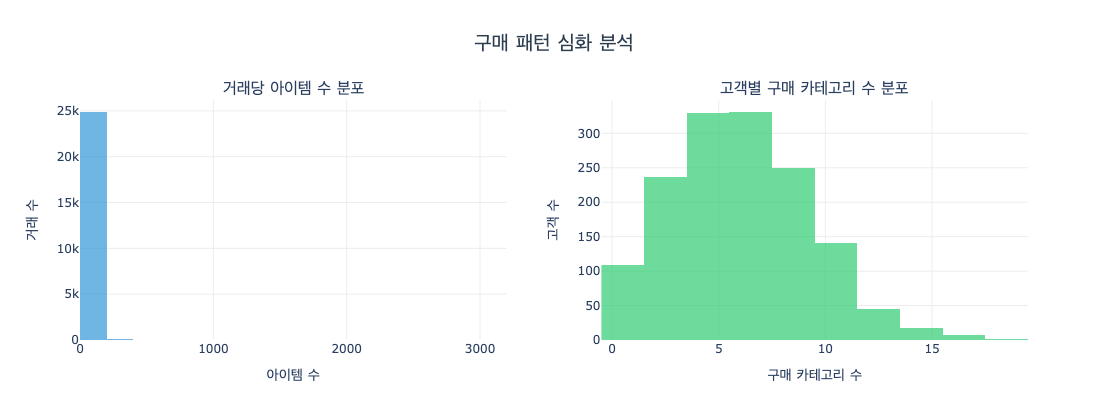

In [46]:
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('거래당 아이템 수 분포', '고객별 구매 카테고리 수 분포')
)

fig.add_trace(go.Histogram(
    x=basket['아이템수'], marker_color='#3498db', opacity=0.7,
    name='아이템수', nbinsx=20
), row=1, col=1)

fig.add_trace(go.Histogram(
    x=cat_div['구매카테고리수'], marker_color='#2ecc71', opacity=0.7,
    name='카테고리수', nbinsx=18
), row=1, col=2)

fig.update_layout(
    title=dict(text='구매 패턴 심화 분석',
               x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50')),
    plot_bgcolor='white', showlegend=False, height=420
)

fig.update_xaxes(title_text='아이템 수', row=1, col=1, gridcolor='#ececec')
fig.update_xaxes(title_text='구매 카테고리 수', row=1, col=2, gridcolor='#ececec')
fig.update_yaxes(title_text='거래 수', row=1, col=1, gridcolor='#ececec')
fig.update_yaxes(title_text='고객 수', row=1, col=2, gridcolor='#ececec')

fig.show()

---
## 10. EDA 인사이트 요약

### 매출 구조
- **Nest-USA** 단일 카테고리가 전체 매출의 약 **54%** 차지 — 특정 카테고리 의존도가 매우 높음
- **Nest-USA**는 거래건수(11,626건)와 매출 모두 1위 — **Apparel**은 거래건수 2위(8,129건)이지만 매출 기여는 13% 수준으로, 거래량과 매출이 반드시 비례하지 않음
- 저단가 다빈도(Apparel, Office) vs 고단가 저빈도(Nest-USA, Nest) 구조 혼재 — 카테고리별 역할이 뚜렷이 다름

### 시간 패턴
- 2019년 하반기, 특히 11~12월에 매출이 집중된다.
- 한 해의 달력 월 차이만으로 반복 계절성을 확정할 수 없으므로 다년도 재검증이 필요하다.
- 매출/광고비 배수는 월 광고비 합계를 분모로 계산한 기술 지표이며, 이익 기반 ROI가 아니다.


### 고객 구매 빈도
- 거래 건수 **중앙값 11건**, 평균 **18.1건**의 우편향 분포 — 75%의 고객이 23건 이하, 최대 327건의 헤비유저 소수가 평균을 끌어올리는 구조
- 이탈 고객 다수와 소수 헤비유저가 공존하는 전형적인 이커머스 구매 패턴

### 고객 재방문 횟수
- 구매일 수 기준으로 전체 고객의 절반이 단일 구매일 고객이다.
- 거래 수와 구매일 수의 차이가 커 같은 날 여러 상품라인·거래가 발생하는 구조다.
- 따라서 거래 건수만으로 고객 재방문 빈도를 해석하지 않는다.


### 고객 인구통계
- 여성 고객군의 총매출이 더 크지만 고객 수도 더 많다.
- 성별 비교는 상품라인 평균이 아니라 고객별 누적지출을 먼저 집계한 뒤 비교한다.
- 쿠폰 사용률은 집계 단위에 따라 다르다: 상품 라인 기준 약 33%, 고객 기준(1회 이상 사용) 약 94%. 전자는 구매 중 쿠폰이 적용된 비중, 후자는 쿠폰을 쓴 적 있는 고객 비중이다.
- 가입기간별 쿠폰·구매 차이는 기술적 연관성이며 고객 유지 효과로 해석하지 않는다.


### 성별 구매 패턴
- **여성**: Apparel·Bags 등 패션·액세서리 카테고리가 거래건수 상위 — 반복 구매 빈도가 높음
- **남성**: Nest-USA·Office 등 고단가 카테고리 비중이 상대적으로 높음
- 카테고리별 구매금액 중앙값은 Nest-USA에서 성별 격차가 가장 크게 나타남 — 남성 고단가 집중 경향을 반영

### 쿠폰/할인

- 할인율이 높을수록 상품 라인 평균 구매액이 낮아지는 패턴(87.55 → 75.26 → 69.38)이 보이지만, 이는 할인이 이미 반영된 금액을 할인율로 그룹핑한 결과다. 세전 금액으로 보면 87.49 / 85.07 / 89.31로 뚜렷한 추세가 없고, 할인 적용 단계에서만 78.74 / 68.05 / 62.51로 벌어진다. 즉 할인율이 높은 그룹의 고객이 더 싼 상품을 사는 것이 아니라, 할인만큼 금액이 깎인 것이다.
- 쿠폰 상태별로도 마찬가지다. 할인 전 라인 평균은 Used 87.18, Not Used 90.53, Clicked 88.29로 큰 차이가 없어, 쿠폰 사용 여부와 구매 상품의 가격대가 연관된다고 보기 어렵다.
- 할인율은 월+카테고리 조합으로 결정되므로 할인율별 비교는 계절 효과와 분리되지 않는다.
- 쿠폰 사용률은 집계 단위에 따라 크게 달라진다. 상품 라인 기준(원본 데이터의 한 행 = 한 거래에서 구매한 상품 한 종류)으로는 약 33%, 고객 기준(1년간 쿠폰을 1회 이상 사용한 고객 비율)으로는 약 94%다. 전자는 "전체 구매 중 쿠폰이 적용된 비중", 후자는 "쿠폰을 써 본 고객의 비중"으로 서로 다른 질문에 답한다. 이후 분석에서 쿠폰 사용률을 인용할 때는 단위를 함께 표기한다.
- 쿠폰의 매출 기여를 판단하려면 쿠폰 노출·발급 로그와 마진 데이터가 필요하다. 현재 데이터로는 쿠폰이 구매를 유발했는지 확인할 수 없다.

### 마케팅 비용
- 월 비용은 일별 marketing 원본을 월별 합산해 계산한다.
- 매출과 채널 비용의 상관은 계절 수요와 동시 집행의 영향을 함께 받는다.
- 중첩된 14일 관측창 분석은 탐색적 연관성으로만 사용하며 채널 효과·ROI로 해석하지 않는다.


### 지역별 구매 패턴
- **Chicago·California** 2개 지역이 고객 수, 평균 구매횟수, 평균 구매금액 모두 상위권
- 전체 매출의 약 **66%** 가 이 두 지역에 집중 — 집중 투자 우선순위가 명확한 핵심 타겟

### 요일별 구매 패턴
- **수-금(Wed·Thu·Fri)** 일평균 거래건수(81-84건)·평균 거래금액(195-212)이 모두 최고 — 주중 중후반에 구매 활동 집중
- **금요일(Fri)** 평균 거래금액 211.75로 가장 높음 — 주말 직전 고단가 구매 경향
- **월-화(Mon·Tue)** 거래건수(41-44건)·평균 거래금액(176)이 모두 최저 — 주초 구매 공백 구간
- 주말(Sat·Sun)은 거래건수 74건으로 중간, 평균 거래금액(181-187)은 월-화보다 높음
- 수-금 집중 패턴을 활용해 주중 중후반에 마케팅 집행을 집중하면 비용 효율 개선 여지 있음

### 장바구니 분석
- 대부분의 거래가 단일 아이템으로 구성 — 크로스셀 기회 존재
- 고객별 구매 카테고리 수가 낮아 카테고리 다변화 여지가 있음

### 다음 분석 방향

EDA에서 확인된 패턴(카테고리 편중, 성별 구매 차이, 지역 집중, 쿠폰 효과)은 고객 개인 단위 분석으로 심화가 필요하다.

- **리텐션 심화** — 코호트별 재구매율, 채널·카테고리·마케팅 비용에 따른 리텐션 차이 (`02_retention`)
- **RFM 세그먼테이션** — 등급별 쿠폰·카테고리·인구통계 패턴 비교, 등급별 마케팅 제언